# Neural Network Fundamentals

## 1. Biological vs Artificial Neuron

The brain contains ~86 billion neurons connected via synapses. An artificial neuron mimics this:

- **Dendrites** → Input features $x_1, x_2, ..., x_n$
- **Synapse strength** → Weights $w_1, w_2, ..., w_n$
- **Cell body** → Weighted sum + bias
- **Axon** → Output after activation

$$z = w_1x_1 + w_2x_2 + ... + w_nx_n + b = \mathbf{w}^T\mathbf{x} + b$$
$$\hat{y} = f(z)$$

where $f$ is an **activation function**.

## 2. Perceptron

The perceptron (Rosenblatt, 1958) is the simplest neural unit:

$$\hat{y} = \text{sign}(\mathbf{w}^T\mathbf{x} + b)$$

**Perceptron learning rule:** If misclassified:
$$\mathbf{w} \leftarrow \mathbf{w} + \eta \cdot y^{(i)} \cdot \mathbf{x}^{(i)}$$

**Limitation:** Can only solve linearly separable problems (XOR problem).

## 3. Multi-Layer Perceptron (MLP)

An MLP stacks layers of neurons:
- **Input layer**: raw features
- **Hidden layers**: learned representations
- **Output layer**: predictions

For a 2-layer network:
$$\mathbf{h} = f^{(1)}(\mathbf{W}^{(1)}\mathbf{x} + \mathbf{b}^{(1)})$$
$$\hat{\mathbf{y}} = f^{(2)}(\mathbf{W}^{(2)}\mathbf{h} + \mathbf{b}^{(2)})$$

**Universal Approximation Theorem**: A single hidden layer MLP with enough neurons can approximate any continuous function.

## 4. Activation Functions

### 4.1 Sigmoid
$$\sigma(x) = \frac{1}{1+e^{-x}}, \quad \sigma'(x) = \sigma(x)(1-\sigma(x))$$
- Output: $(0, 1)$. Used in binary classification output.
- **Problem**: Vanishing gradients for $|x| >> 0$.

### 4.2 Tanh
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}, \quad \tanh'(x) = 1 - \tanh^2(x)$$
- Output: $(-1, 1)$. Zero-centered (better than sigmoid).

### 4.3 ReLU (Rectified Linear Unit)
$$f(x) = \max(0, x), \quad f'(x) = \begin{cases} 1 & x > 0 \\ 0 & x \leq 0 \end{cases}$$
- **Default choice** for hidden layers. Fast, sparse activations.
- **Problem**: Dying ReLU (neurons stuck at 0).

### 4.4 Leaky ReLU
$$f(x) = \begin{cases} x & x > 0 \\ \alpha x & x \leq 0 \end{cases}, \quad \alpha = 0.01$$

### 4.5 PReLU (Parametric ReLU)
Same as Leaky ReLU but $\alpha$ is **learned** during training.

### 4.6 ELU (Exponential Linear Unit)
$$f(x) = \begin{cases} x & x > 0 \\ \alpha(e^x - 1) & x \leq 0 \end{cases}$$
- Negative values push mean closer to zero.

### 4.7 SELU (Scaled ELU)
$$f(x) = \lambda \begin{cases} x & x > 0 \\ \alpha(e^x - 1) & x \leq 0 \end{cases}$$
where $\lambda \approx 1.0507$, $\alpha \approx 1.6733$. **Self-normalizing** networks.

### 4.8 GELU (Gaussian Error Linear Unit)
$$\text{GELU}(x) = x \cdot \Phi(x) = x \cdot \frac{1}{2}\left[1 + \text{erf}\left(\frac{x}{\sqrt{2}}\right)\right]$$
- Used in BERT, GPT. Smooth, probabilistic gating.

### 4.9 Swish
$$\text{Swish}(x) = x \cdot \sigma(\beta x) = \frac{x}{1+e^{-\beta x}}$$
- Discovered by Google Brain via neural architecture search.

### 4.10 Mish
$$\text{Mish}(x) = x \cdot \tanh(\text{softplus}(x)) = x \cdot \tanh(\ln(1+e^x))$$

### 4.11 Softmax
$$\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}}$$
- Converts logits to probabilities. Used in multi-class output layer.
- **Numerically stable version**: subtract $\max(\mathbf{z})$ before exponentiating.

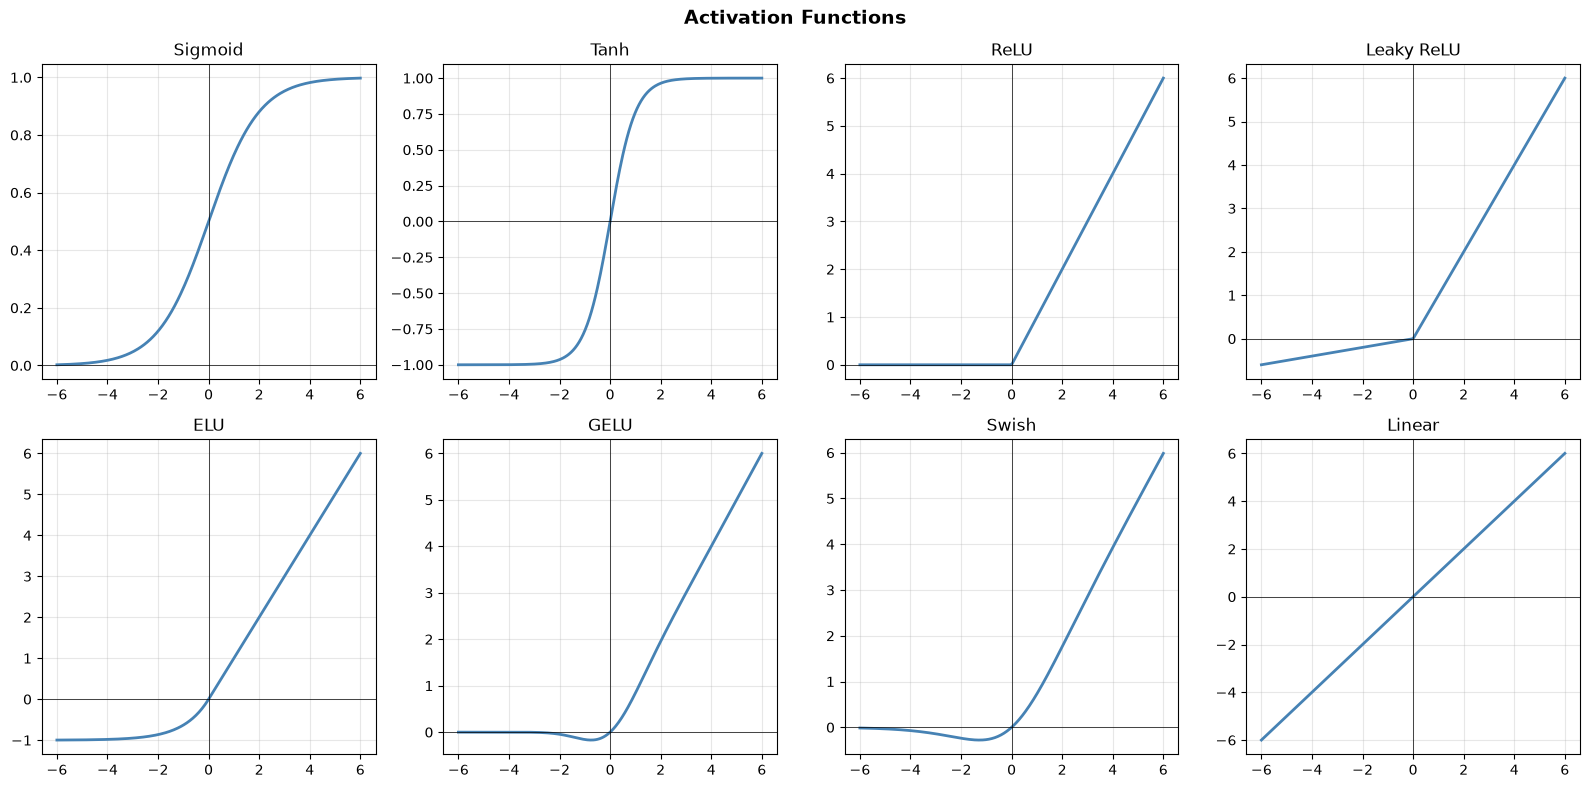

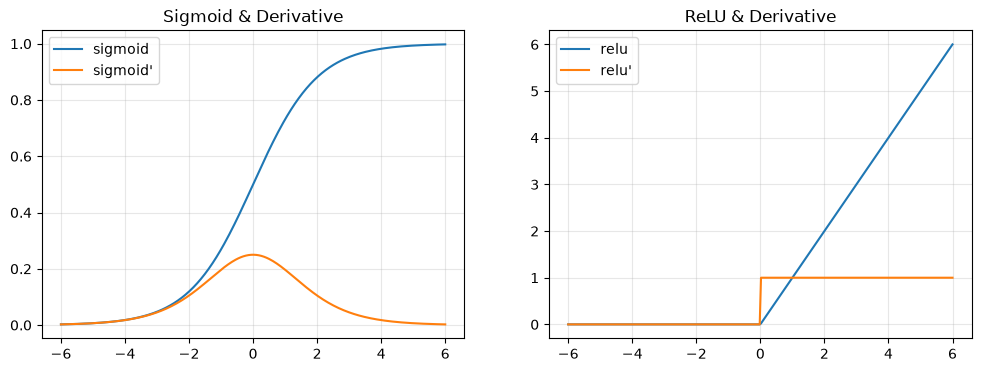

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 300)

def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x): return np.tanh(x)
def relu(x): return np.maximum(0, x)
def leaky_relu(x, alpha=0.1): return np.where(x > 0, x, alpha * x)
def elu(x, alpha=1.0): return np.where(x > 0, x, alpha * (np.exp(x) - 1))
def gelu(x): return x * 0.5 * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))
def swish(x): return x * sigmoid(x)
def softmax(x): e = np.exp(x - np.max(x)); return e / e.sum()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fns = [(sigmoid,'Sigmoid'), (tanh,'Tanh'), (relu,'ReLU'), (leaky_relu,'Leaky ReLU'),
       (elu,'ELU'), (gelu,'GELU'), (swish,'Swish'),
       (lambda x: x, 'Linear')]
for ax, (fn, name) in zip(axes.flat, fns):
    ax.plot(x, fn(x), lw=2, color='steelblue')
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_title(name); ax.grid(True, alpha=0.3)
plt.suptitle('Activation Functions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Derivative comparison
dx = 1e-5
dsigmoid = (sigmoid(x+dx) - sigmoid(x-dx)) / (2*dx)
drelu = (relu(x+dx) - relu(x-dx)) / (2*dx)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12,4))
a1.plot(x, sigmoid(x), label='sigmoid'); a1.plot(x, dsigmoid, label="sigmoid'")
a1.legend(); a1.set_title("Sigmoid & Derivative"); a1.grid(True, alpha=0.3)
a2.plot(x, relu(x), label='relu'); a2.plot(x, drelu, label="relu'")
a2.legend(); a2.set_title("ReLU & Derivative"); a2.grid(True, alpha=0.3)
plt.show()

## 5. Loss Functions

### 5.1 Mean Squared Error (MSE) Regression
$$\mathcal{L}_{MSE} = \frac{1}{m}\sum_{i=1}^m (\hat{y}^{(i)} - y^{(i)})^2$$

### 5.2 Mean Absolute Error (MAE)
$$\mathcal{L}_{MAE} = \frac{1}{m}\sum_{i=1}^m |\hat{y}^{(i)} - y^{(i)}|$$

### 5.3 Huber Loss (Smooth L1)
$$\mathcal{L}_{\delta}(y, \hat{y}) = \begin{cases} \frac{1}{2}(y-\hat{y})^2 & |y-\hat{y}| \leq \delta \\ \delta|y-\hat{y}| - \frac{1}{2}\delta^2 & \text{otherwise} \end{cases}$$
Robust to outliers.

### 5.4 Binary Cross-Entropy (BCE)
$$\mathcal{L}_{BCE} = -\frac{1}{m}\sum_{i=1}^m \left[y^{(i)}\log(\hat{y}^{(i)}) + (1-y^{(i)})\log(1-\hat{y}^{(i)})\right]$$

### 5.5 Categorical Cross-Entropy
$$\mathcal{L}_{CE} = -\frac{1}{m}\sum_{i=1}^m \sum_{k=1}^K y_k^{(i)} \log(\hat{y}_k^{(i)})$$

### 5.6 Focal Loss (for imbalanced data)
$$\mathcal{L}_{FL} = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$
where $(1-p_t)^\gamma$ down-weights easy examples. Used in RetinaNet object detection.

### 5.7 KL Divergence
$$D_{KL}(P||Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)}$$

## 6. Backpropagation

Backpropagation applies the **chain rule** to compute gradients through a computation graph.

### Chain Rule
If $z = f(y)$ and $y = g(x)$:
$$\frac{\partial z}{\partial x} = \frac{\partial z}{\partial y} \cdot \frac{\partial y}{\partial x}$$

### For a 2-layer network:

**Forward pass:**
$$z^{[1]} = W^{[1]}x + b^{[1]}, \quad a^{[1]} = \sigma(z^{[1]})$$
$$z^{[2]} = W^{[2]}a^{[1]} + b^{[2]}, \quad \hat{y} = \sigma(z^{[2]})$$

**Backward pass (BCE loss):**
$$\frac{\partial \mathcal{L}}{\partial z^{[2]}} = \hat{y} - y$$
$$\frac{\partial \mathcal{L}}{\partial W^{[2]}} = \frac{\partial \mathcal{L}}{\partial z^{[2]}} \cdot (a^{[1]})^T$$
$$\frac{\partial \mathcal{L}}{\partial a^{[1]}} = (W^{[2]})^T \cdot \frac{\partial \mathcal{L}}{\partial z^{[2]}}$$
$$\frac{\partial \mathcal{L}}{\partial z^{[1]}} = \frac{\partial \mathcal{L}}{\partial a^{[1]}} \odot \sigma'(z^{[1]})$$
$$\frac{\partial \mathcal{L}}{\partial W^{[1]}} = \frac{\partial \mathcal{L}}{\partial z^{[1]}} \cdot x^T$$

## 7. Weight Initialization

Poor initialization → vanishing/exploding gradients.

### Xavier/Glorot Initialization
$$\text{Var}(W) = \frac{2}{n_{in} + n_{out}}$$
$$W \sim \mathcal{U}\left(-\sqrt{\frac{6}{n_{in}+n_{out}}}, \sqrt{\frac{6}{n_{in}+n_{out}}}\right)$$
Best for: Sigmoid, Tanh.

### He Initialization
$$\text{Var}(W) = \frac{2}{n_{in}}$$
$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{in}}}\right)$$
Best for: ReLU and variants.

## 8. Batch Normalization

Normalizes layer inputs to stabilize training (Ioffe & Szegedy, 2015):

$$\mu_B = \frac{1}{m}\sum_{i=1}^m x_i, \quad \sigma_B^2 = \frac{1}{m}\sum_{i=1}^m (x_i - \mu_B)^2$$
$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y_i = \gamma\hat{x}_i + \beta$$

$\gamma$ and $\beta$ are **learnable parameters**. $\epsilon \approx 10^{-5}$ for numerical stability.

## 9. Layer Normalization

Normalizes **across features** (not batch). Used in Transformers:
$$\mu = \frac{1}{H}\sum_{i=1}^H x_i, \quad \sigma^2 = \frac{1}{H}\sum_{i=1}^H (x_i - \mu)^2$$
$$\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}, \quad y_i = \gamma\hat{x}_i + \beta$$

## 10. Dropout Regularization

Randomly sets neurons to 0 during training with probability $p$:
$$\tilde{h}_i = \frac{r_i \cdot h_i}{1-p}, \quad r_i \sim \text{Bernoulli}(1-p)$$

Division by $(1-p)$ is **inverted dropout** keeps expected output the same at test time.

Epoch     0 | Loss: 1.3165
Epoch   500 | Loss: 0.0081
Epoch  1000 | Loss: 0.0024


Epoch  1500 | Loss: 0.0013
Epoch  2000 | Loss: 0.0009
Epoch  2500 | Loss: 0.0006

Predictions: [0 1 1 0]
True labels: [0 1 1 0]


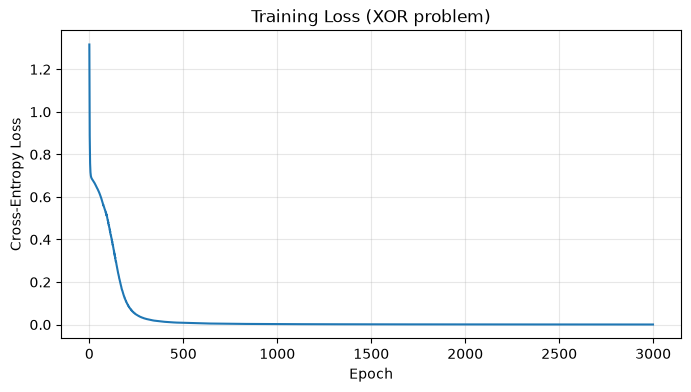

In [2]:
import numpy as np

# ============================================================
# MLP from Scratch with NumPy
# ============================================================

class MLP:
    def __init__(self, layer_sizes, lr=0.01):
        self.lr = lr
        self.weights = []
        self.biases = []
        # He initialization
        for i in range(len(layer_sizes)-1):
            W = np.random.randn(layer_sizes[i+1], layer_sizes[i]) * np.sqrt(2.0/layer_sizes[i])
            b = np.zeros((layer_sizes[i+1], 1))
            self.weights.append(W)
            self.biases.append(b)

    def relu(self, z): return np.maximum(0, z)
    def relu_grad(self, z): return (z > 0).astype(float)
    def sigmoid(self, z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    def softmax(self, z):
        e = np.exp(z - np.max(z, axis=0, keepdims=True))
        return e / e.sum(axis=0, keepdims=True)

    def forward(self, X):
        self.cache = {'A0': X}
        A = X
        L = len(self.weights)
        for l, (W, b) in enumerate(zip(self.weights, self.biases)):
            Z = W @ A + b
            self.cache[f'Z{l+1}'] = Z
            if l < L - 1:
                A = self.relu(Z)
            else:
                A = self.softmax(Z)  # output layer
            self.cache[f'A{l+1}'] = A
        return A

    def compute_loss(self, Y_pred, Y_true):
        m = Y_true.shape[1]
        return -np.sum(Y_true * np.log(Y_pred + 1e-8)) / m

    def backward(self, Y_true):
        m = Y_true.shape[1]
        L = len(self.weights)
        grads = {}
        # Output layer gradient (softmax + cross-entropy combined)
        dA = self.cache[f'A{L}'] - Y_true
        for l in range(L-1, -1, -1):
            A_prev = self.cache[f'A{l}']
            Z = self.cache[f'Z{l+1}']
            if l < L - 1:
                dZ = dA * self.relu_grad(Z)
            else:
                dZ = dA
            grads[f'dW{l+1}'] = dZ @ A_prev.T / m
            grads[f'db{l+1}'] = dZ.mean(axis=1, keepdims=True)
            dA = self.weights[l].T @ dZ
        return grads

    def update(self, grads):
        for l in range(len(self.weights)):
            self.weights[l] -= self.lr * grads[f'dW{l+1}']
            self.biases[l]  -= self.lr * grads[f'db{l+1}']

    def fit(self, X, Y, epochs=1000, verbose=100):
        losses = []
        for ep in range(epochs):
            Y_pred = self.forward(X)
            loss = self.compute_loss(Y_pred, Y)
            losses.append(loss)
            grads = self.backward(Y)
            self.update(grads)
            if ep % verbose == 0:
                print(f'Epoch {ep:5d} | Loss: {loss:.4f}')
        return losses

    def predict(self, X):
        return np.argmax(self.forward(X), axis=0)


# --- Train on XOR ---
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]]).T   # (2, 4)
Y_raw = np.array([0, 1, 1, 0])
Y_xor = np.eye(2)[Y_raw].T                       # one-hot (2, 4)

np.random.seed(42)
mlp = MLP([2, 8, 8, 2], lr=0.1)
losses = mlp.fit(X_xor, Y_xor, epochs=3000, verbose=500)
print('\nPredictions:', mlp.predict(X_xor))
print('True labels:', Y_raw)

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title('Training Loss (XOR problem)')
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.grid(True, alpha=0.3)
plt.show()

MLPTorch(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=3, bias=True)
  )
)
Parameters: 13,571



Test Accuracy: 0.9150


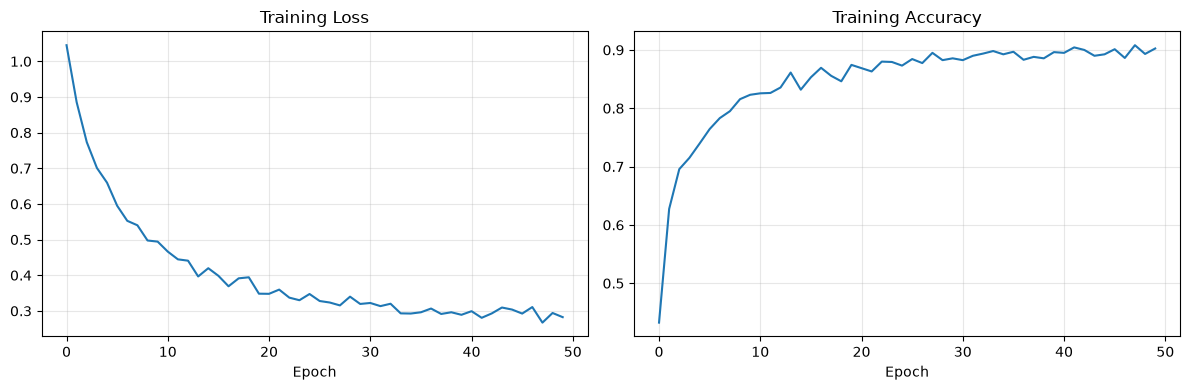

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Generate dataset ---
X, y = make_classification(n_samples=2000, n_features=20, n_informative=15,
                            n_classes=3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

train_ds = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
test_ds  = TensorDataset(torch.FloatTensor(X_test),  torch.LongTensor(y_test))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

# --- PyTorch MLP ---
class MLPTorch(nn.Module):
    def __init__(self, in_dim, hidden_dims, out_dim, dropout_p=0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout_p)
            ]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLPTorch(20, [128, 64, 32], 3).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# --- Training loop ---
train_losses, train_accs = [], []
for epoch in range(50):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == yb).sum().item()
        total += yb.size(0)
    scheduler.step()
    train_losses.append(total_loss / len(train_loader))
    train_accs.append(correct / total)

# Evaluate
model.eval()
with torch.no_grad():
    Xt = torch.FloatTensor(X_test).to(device)
    yt = torch.LongTensor(y_test).to(device)
    preds = model(Xt).argmax(1)
    acc = (preds == yt).float().mean().item()
print(f'\nTest Accuracy: {acc:.4f}')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(train_losses); a1.set_title('Training Loss'); a1.set_xlabel('Epoch')
a2.plot(train_accs);   a2.set_title('Training Accuracy'); a2.set_xlabel('Epoch')
for ax in [a1, a2]: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [4]:
# --- Weight Initialization comparison ---
import torch
import torch.nn as nn

def build_model(init='he'):
    layers = []
    for _ in range(10):
        layer = nn.Linear(512, 512)
        if init == 'zeros':
            nn.init.zeros_(layer.weight)
        elif init == 'he':
            nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')
        elif init == 'xavier':
            nn.init.xavier_normal_(layer.weight)
        layers += [layer, nn.ReLU()]
    return nn.Sequential(*layers)

x_sample = torch.randn(64, 512)
for init_type in ['zeros', 'xavier', 'he']:
    m = build_model(init_type)
    with torch.no_grad():
        out = m(x_sample)
    print(f'{init_type:8s} | mean={out.mean():.4f}, std={out.std():.4f}')

# Batch Normalization demo
print('\n--- Batch Normalization ---')
bn = nn.BatchNorm1d(512)
x_raw = torch.randn(64, 512) * 10 + 5
x_normed = bn(x_raw)
print(f'Before BN | mean={x_raw.mean():.2f}, std={x_raw.std():.2f}')
print(f'After  BN | mean={x_normed.mean():.4f}, std={x_normed.std():.4f}')

zeros    | mean=0.0119, std=0.0146
xavier   | mean=0.0256, std=0.0363
he       | mean=0.5215, std=0.7485

--- Batch Normalization ---
Before BN | mean=4.98, std=10.00
After  BN | mean=0.0000, std=1.0000


## Additional Learning Resources

### Foundational Books
- **Deep Learning** Goodfellow, Bengio, Courville: https://www.deeplearningbook.org/
- **Neural Networks and Deep Learning** Michael Nielsen: http://neuralnetworksanddeeplearning.com/
- **Dive into Deep Learning** d2l.ai: https://d2l.ai/

### Video Lectures
- **3Blue1Brown Neural Networks Series**: https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi
- **Andrej Karpathy Neural Networks: Zero to Hero**: https://www.youtube.com/playlist?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ
- **Stanford CS231n**: http://cs231n.stanford.edu/
- **MIT 6.S191 Introduction to Deep Learning**: http://introtodeeplearning.com/

### Key Papers
- **Batch Normalization** (Ioffe & Szegedy, 2015): https://arxiv.org/abs/1502.03167
- **Dropout** (Srivastava et al., 2014): https://jmlr.org/papers/v15/srivastava14a.html
- **He Initialization** (He et al., 2015): https://arxiv.org/abs/1502.01852
- **Xavier Initialization** (Glorot & Bengio, 2010): http://proceedings.mlr.press/v9/glorot10a.html
- **GELU** (Hendrycks & Gimpel, 2016): https://arxiv.org/abs/1606.08415
- **Swish** (Ramachandran et al., 2017): https://arxiv.org/abs/1710.05941
- **Focal Loss** (Lin et al., 2017): https://arxiv.org/abs/1708.02002

### Interactive Resources
- **Neural Network Playground (TensorFlow)**: https://playground.tensorflow.org/
- **Backpropagation Visual Demo**: https://karpathy.github.io/neuralnets/
- **PyTorch Tutorials**: https://pytorch.org/tutorials/